Hệ thống khởi tạo: 676 cảm biến (Lưới 0.2m)
--- Bắt đầu sinh 20000 mẫu dữ liệu... ---
Đã sinh 5000/20000 mẫu...
Đã sinh 10000/20000 mẫu...
Đã sinh 15000/20000 mẫu...
Đã sinh 20000/20000 mẫu...
Hoàn tất. Thời gian: 8.21s

=== BẮT ĐẦU QUY TRÌNH HUẤN LUYỆN & SO SÁNH ===
Samples: Train=16000, Valid=2000, Test=2000

[1] Training Deep Learning Model...
Iteration 1, loss = 0.14056129
Iteration 2, loss = 0.05595435
Iteration 3, loss = 0.04123146
Iteration 4, loss = 0.03238356
Iteration 5, loss = 0.02746039
Iteration 6, loss = 0.02261389
Iteration 7, loss = 0.01925429
Iteration 8, loss = 0.01770681
Iteration 9, loss = 0.01587617
Iteration 10, loss = 0.01474255
Iteration 11, loss = 0.01330709
Iteration 12, loss = 0.01284445
Iteration 13, loss = 0.01211642
Iteration 14, loss = 0.01042293
Iteration 15, loss = 0.00988724
Iteration 16, loss = 0.00932774
Iteration 17, loss = 0.00885132
Iteration 18, loss = 0.00876356
Iteration 19, loss = 0.00782800
Iteration 20, loss = 0.00742994
Iteration 21, loss =

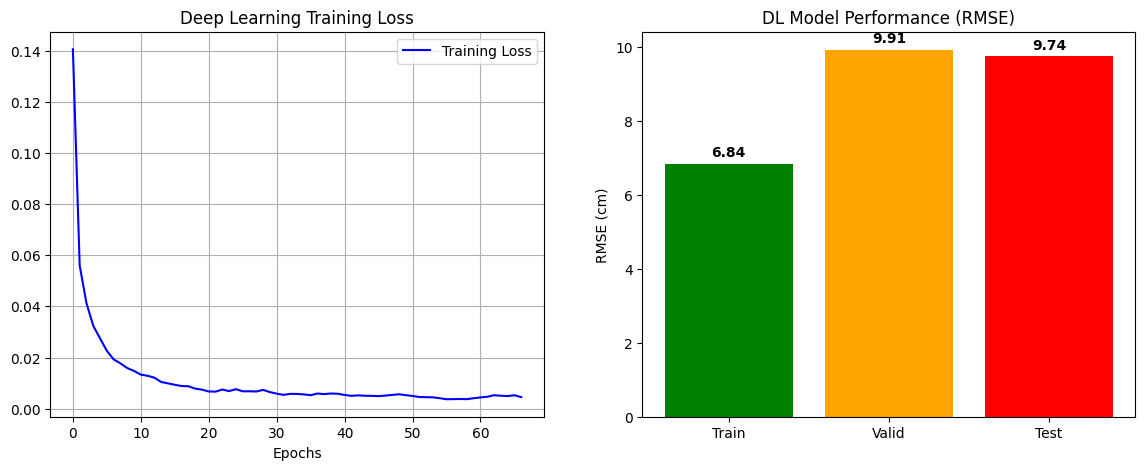

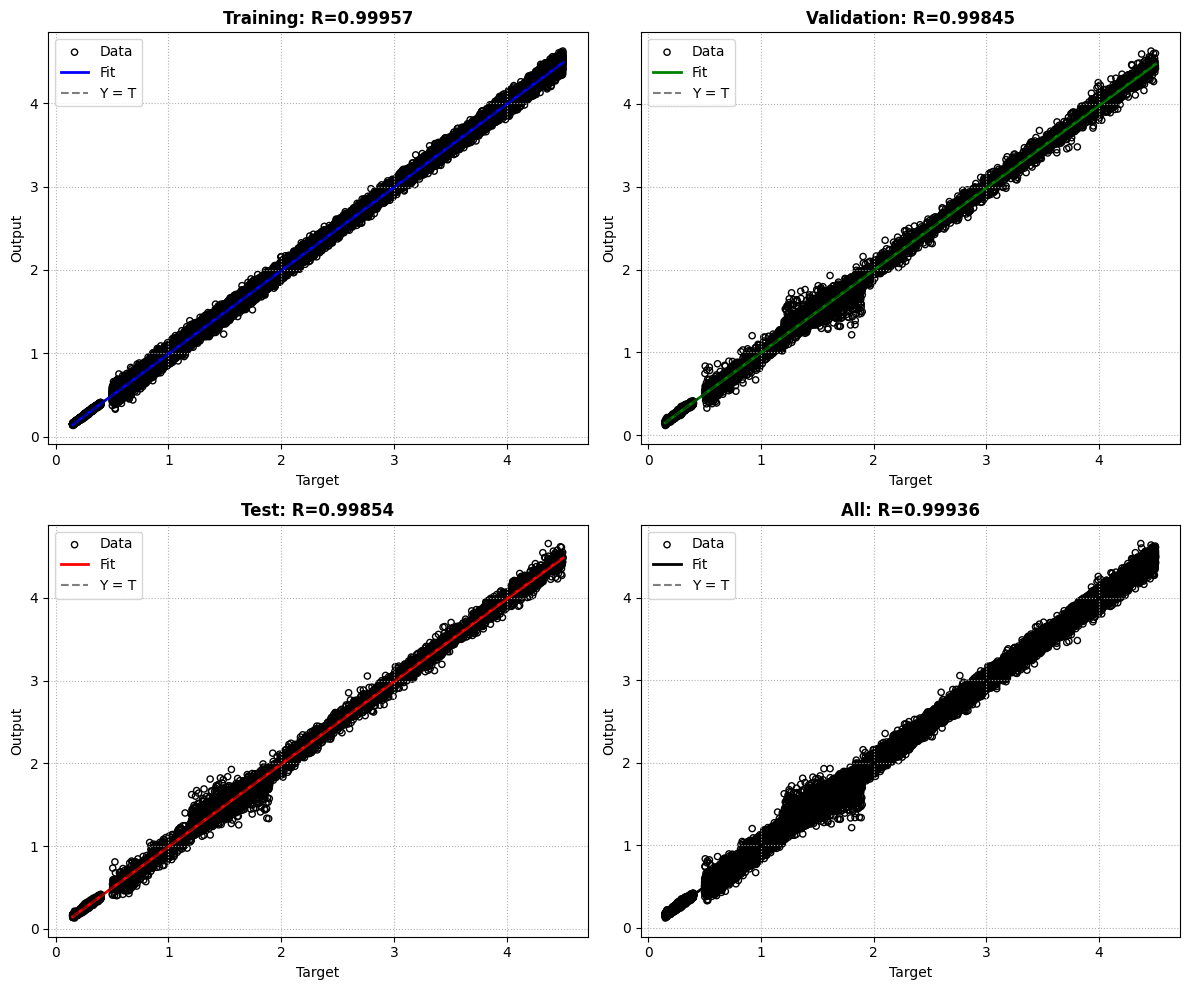

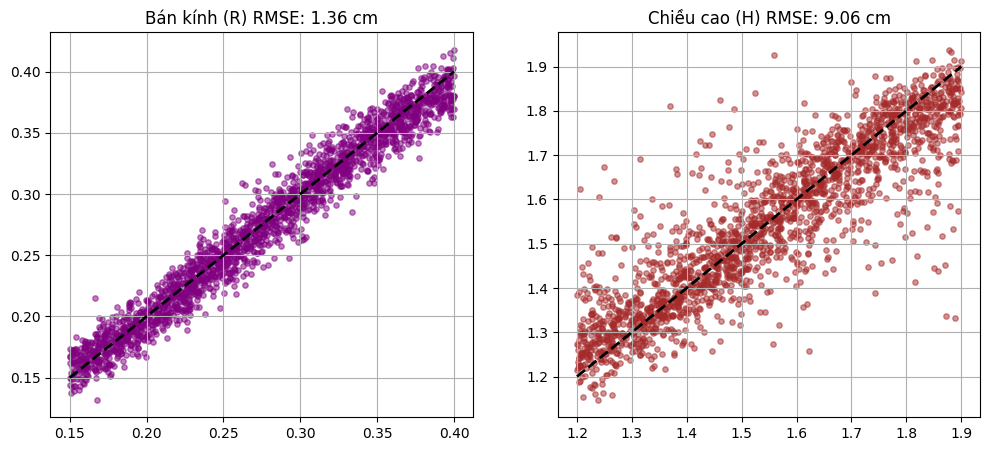

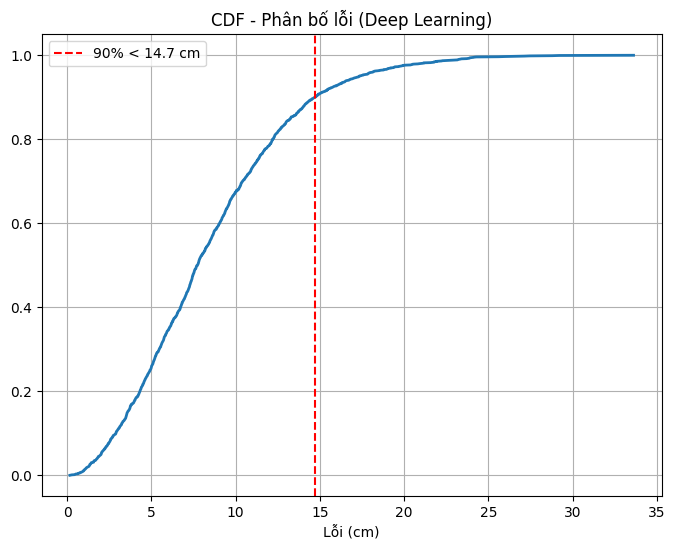

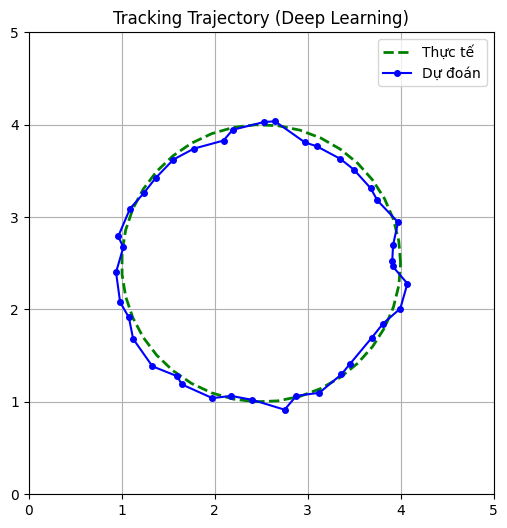

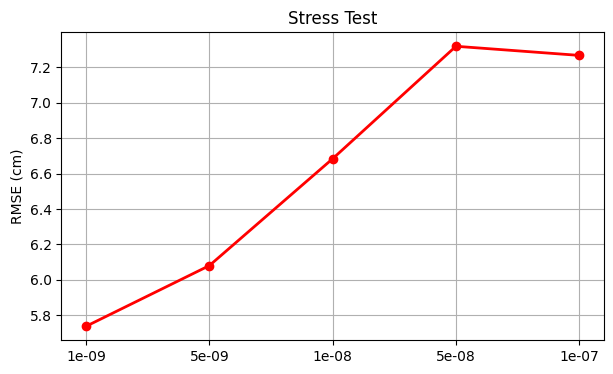

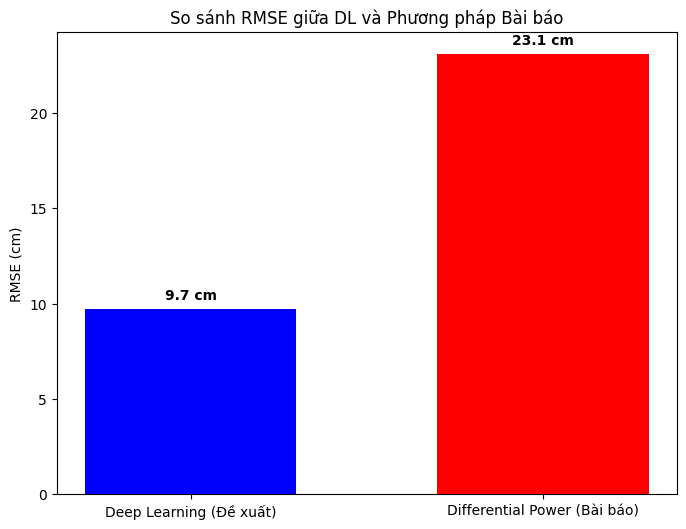

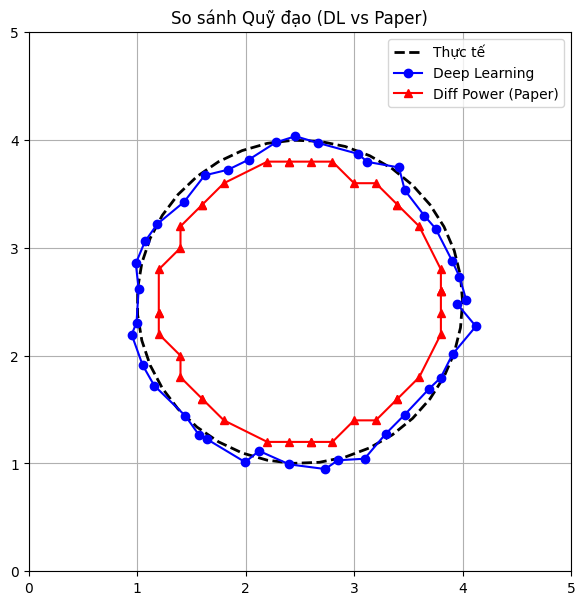

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import time

# ==============================================================================
# 1. CẤU HÌNH HỆ THỐNG
# ==============================================================================
ROOM_DIM = [5, 5, 3]    
GRID_SIZE = 0.2         
N_SAMPLES = 20000       
MIN_VISIBLE_SENSORS = 1 

LED_POWER = 10.0        
SEMI_ANGLE = 60         
LAMBERTIAN_ORDER = -np.log(2) / np.log(np.cos(np.radians(SEMI_ANGLE)))

PD_AREA = 1e-4          
FOV = 60                
REFRACTIVE_INDEX = 1.5
FILTER_GAIN = 1.0
CONC_GAIN = (REFRACTIVE_INDEX**2) / (np.sin(np.radians(FOV))**2)

LED_POSITIONS = np.array([
    [1.25, 1.25, 3.0], 
    [3.75, 1.25, 3.0],
    [3.75, 3.75, 3.0], 
    [1.25, 3.75, 3.0]
])

# ==============================================================================
# 2. SIMULATOR
# ==============================================================================
class VLPSimulator:
    def __init__(self, room_dim, grid_size):
        self.L, self.W, self.H = room_dim
        self.grid_size = grid_size
        x = np.arange(0, self.L + grid_size/100, grid_size)
        y = np.arange(0, self.W + grid_size/100, grid_size)
        self.X_grid, self.Y_grid = np.meshgrid(x, y)
        self.rx_coords = np.column_stack((self.X_grid.ravel(), self.Y_grid.ravel(), np.zeros(self.X_grid.size)))
        self.n_sensors = self.rx_coords.shape[0]
        print(f"Hệ thống khởi tạo: {self.n_sensors} cảm biến (Lưới {grid_size}m)")

    def calculate_los_channel(self, led_pos, rx_pos_list, obj_params=None):
        vec_d = rx_pos_list - led_pos
        dist = np.linalg.norm(vec_d, axis=1)
        dist_sq = dist ** 2
        cos_phi = -vec_d[:, 2] / dist
        cos_psi = -vec_d[:, 2] / dist 
        H = np.zeros(len(dist))
        fov_rad = np.radians(FOV)
        valid_indices = (cos_psi >= np.cos(fov_rad)) & (cos_phi > 0)
        const_factor = ((LAMBERTIAN_ORDER + 1) * PD_AREA) / (2 * np.pi)
        H[valid_indices] = (const_factor / dist_sq[valid_indices]) * \
                           (cos_phi[valid_indices] ** LAMBERTIAN_ORDER) * \
                           cos_psi[valid_indices] * FILTER_GAIN * CONC_GAIN

        if obj_params is not None:
            ox, oy, r, h = obj_params
            p1 = led_pos[:2]; p2 = rx_pos_list[:, :2]
            d_vec = p2 - p1; f_vec = p1 - np.array([ox, oy])
            a = np.sum(d_vec**2, axis=1); b = np.sum(d_vec * f_vec, axis=1)
            c = np.sum(f_vec**2) - r**2; delta = b**2 - a*c
            pot_idx = np.where(delta >= 0)
            if len(pot_idx[0]) > 0:
                sqrt_delta = np.sqrt(delta[pot_idx])
                t1 = (-b[pot_idx] - sqrt_delta) / a[pot_idx]
                t2 = (-b[pot_idx] + sqrt_delta) / a[pot_idx]
                t_start = np.maximum(0, t1); t_end = np.minimum(1, t2)
                valid_intersect = t_start < t_end
                real_idx = pot_idx[0][valid_intersect]
                t_end_real = t_end[valid_intersect]
                z_at_exit = self.H * (1 - t_end_real)
                is_blocked = z_at_exit < h
                H[real_idx[is_blocked]] = 0.0
        return H

# ==============================================================================
# 3. DATA GENERATION
# ==============================================================================
def generate_training_data(sim, n_samples):
    X = []
    y = []
    print(f"--- Bắt đầu sinh {n_samples} mẫu dữ liệu... ---")
    start_time = time.time()
    count = 0
    cos_threshold = np.cos(np.radians(SEMI_ANGLE))
    
    while count < n_samples:
        ox = np.random.uniform(0.5, sim.L - 0.5)
        oy = np.random.uniform(0.5, sim.W - 0.5)
        r = np.random.uniform(0.15, 0.40) 
        h = np.random.uniform(1.2, 1.9)   
        obj = [ox, oy, r, h]
        
        visible_led_count = 0
        obj_top = np.array([ox, oy, h])
        for led in LED_POSITIONS:
            vec = led - obj_top
            if abs(vec[2]) / np.linalg.norm(vec) > cos_threshold: visible_led_count += 1
        
        if visible_led_count < MIN_VISIBLE_SENSORS: continue 
            
        rss_features = []
        for led in LED_POSITIONS:
            h_channel = sim.calculate_los_channel(led, sim.rx_coords, obj_params=obj)
            p_rx = h_channel * LED_POWER
            noise = np.random.normal(0, 1e-8, size=len(p_rx))
            p_rx_noisy = np.maximum(p_rx + noise, 1e-12)
            p_rx_log = 10 * np.log10(p_rx_noisy) # Log Transform
            rss_features.append(p_rx_log)
            
        X.append(np.concatenate(rss_features))
        y.append(obj)
        count += 1
        if count % 5000 == 0: print(f"Đã sinh {count}/{n_samples} mẫu...")
            
    print(f"Hoàn tất. Thời gian: {time.time() - start_time:.2f}s")
    return np.array(X), np.array(y)

# ==============================================================================
# 4. PHƯƠNG PHÁP BÀI BÁO (DIFFERENTIAL POWER PROFILE)
# ==============================================================================
def calculate_p0_reference(sim):
    """Tính P0 (Công suất phòng trống) - Tham chiếu cho bài báo"""
    print("--- [Paper Method] Đang tính P0 (Empty Room)... ---")
    p0_total = np.zeros(sim.n_sensors)
    for led in LED_POSITIONS:
        h = sim.calculate_los_channel(led, sim.rx_coords, obj_params=None)
        p0_total += (h * LED_POWER)
    return p0_total

def predict_paper_method(X_log_data, p0_ref, sim):
    """
    Thuật toán Non-DL từ bài báo: Tìm vị trí có độ sụt giảm công suất lớn nhất.
    Delta_F = P0 - P_observed
    """
    n_samples = X_log_data.shape[0]
    preds = []
    
    for i in range(n_samples):
        # 1. Tái tạo công suất tuyến tính (Watts) từ Log Input
        sample_log = X_log_data[i].reshape(4, sim.n_sensors)
        sample_watts = 10**(sample_log / 10.0)
        
        # 2. Tổng hợp công suất thu tại mỗi cảm biến
        p_observed_total = np.sum(sample_watts, axis=0)
        
        # 3. Tính Differential Power (Delta F)
        diff_profile = p0_ref - p_observed_total
        
        # 4. Tìm đỉnh (Peak) -> Vị trí vật thể
        max_idx = np.argmax(diff_profile)
        pred_pos = sim.rx_coords[max_idx]
        
        preds.append([pred_pos[0], pred_pos[1]])
        
    return np.array(preds)

# ==============================================================================
# 5. VISUALIZATION (FULL SUITE)
# ==============================================================================
def plot_learning_curve(model, train_rmse, val_rmse, test_rmse):
    """Vẽ Learning Curve và Bar Chart so sánh 3 tập dữ liệu"""
    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(model.loss_curve_, label='Training Loss', color='blue')
    plt.title('Deep Learning Training Loss'); plt.xlabel('Epochs'); plt.grid(True); plt.legend()
    
    plt.subplot(1, 2, 2)
    sets = ['Train', 'Valid', 'Test']
    values = [train_rmse, val_rmse, test_rmse]
    bars = plt.bar(sets, values, color=['green', 'orange', 'red'])
    plt.title('DL Model Performance (RMSE)'); plt.ylabel('RMSE (cm)')
    for bar in bars:
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.2, f'{bar.get_height():.2f}', ha='center', fontweight='bold')

def plot_matlab_style_regression(y_train_true, y_train_pred, y_val_true, y_val_pred, y_test_true, y_test_pred):
    """Vẽ biểu đồ tương quan R-Value phong cách MATLAB"""
    y_all_true = np.concatenate([y_train_true, y_val_true, y_test_true])
    y_all_pred = np.concatenate([y_train_pred, y_val_pred, y_test_pred])
    datasets = [(y_train_true, y_train_pred, 'Training'), (y_val_true, y_val_pred, 'Validation'),
                (y_test_true, y_test_pred, 'Test'), (y_all_true, y_all_pred, 'All')]
    
    fig, axs = plt.subplots(2, 2, figsize=(12, 10))
    axs = axs.ravel()
    for i, (true, pred, title) in enumerate(datasets):
        ax = axs[i]
        t = true.flatten(); o = pred.flatten()
        R = np.corrcoef(t, o)[0, 1] if len(t) > 1 else 0
        slope, intercept = np.polyfit(t, o, 1) if len(t) > 1 else (1, 0)
        
        ax.scatter(t, o, facecolors='none', edgecolors='k', s=20, label='Data')
        x_vals = np.array([min(t), max(t)])
        ax.plot(x_vals, slope * x_vals + intercept, color=['blue', 'green', 'red', 'black'][i], linewidth=2, label='Fit')
        ax.plot([min(t), max(t)], [min(t), max(t)], 'k--', alpha=0.5, label='Y = T')
        ax.set_title(f'{title}: R={R:.5f}', fontweight='bold')
        ax.set_xlabel('Target'); ax.set_ylabel('Output'); ax.legend(loc='upper left'); ax.grid(True, linestyle=':')
    plt.tight_layout()

def plot_parameter_estimation(y_true, y_pred):
    """Đánh giá khả năng dự đoán R và H"""
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.scatter(y_true[:, 2], y_pred[:, 2], alpha=0.5, color='purple', s=15)
    plt.plot([0.15, 0.4], [0.15, 0.4], 'k--', lw=2, label='Ideal')
    rmse_r = np.sqrt(mean_squared_error(y_true[:,2], y_pred[:,2])) * 100
    plt.title(f'Bán kính (R) RMSE: {rmse_r:.2f} cm'); plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.scatter(y_true[:, 3], y_pred[:, 3], alpha=0.5, color='brown', s=15)
    plt.plot([1.2, 1.9], [1.2, 1.9], 'k--', lw=2, label='Ideal')
    rmse_h = np.sqrt(mean_squared_error(y_true[:,3], y_pred[:,3])) * 100
    plt.title(f'Chiều cao (H) RMSE: {rmse_h:.2f} cm'); plt.grid(True)

def plot_cdf_error(y_true, y_pred):
    """Vẽ CDF phân bố lỗi cho Deep Learning"""
    errors = np.sqrt((y_true[:, 0] - y_pred[:, 0])**2 + (y_true[:, 1] - y_pred[:, 1])**2)
    errors_sorted = np.sort(errors)
    p = 1. * np.arange(len(errors)) / (len(errors) - 1)
    p90 = np.percentile(errors, 90)
    plt.figure(figsize=(8, 6))
    plt.plot(errors_sorted * 100, p, linewidth=2)
    plt.axvline(x=p90*100, color='r', linestyle='--', label=f'90% < {p90*100:.1f} cm')
    plt.title('CDF - Phân bố lỗi (Deep Learning)'); plt.xlabel('Lỗi (cm)'); plt.grid(True); plt.legend()

def visualize_trajectory(sim, model, scaler_X, scaler_y):
    """Vẽ quỹ đạo test riêng cho Deep Learning"""
    print("\n--- Đang vẽ quỹ đạo (Test)... ---")
    theta = np.linspace(0, 2*np.pi, 40)
    path_x = 2.5 + 1.5 * np.cos(theta); path_y = 2.5 + 1.5 * np.sin(theta)
    pred_path = []
    
    for i in range(len(path_x)):
        obj = [path_x[i], path_y[i], 0.3, 1.6]
        rss_features = []
        for led in LED_POSITIONS:
            h_val = sim.calculate_los_channel(led, sim.rx_coords, obj_params=obj)
            p_rx = h_val * LED_POWER
            noise = np.random.normal(0, 1e-8, size=len(p_rx))
            rss_features.append(10 * np.log10(np.maximum(p_rx + noise, 1e-12)))
        X_in = scaler_X.transform(np.concatenate(rss_features).reshape(1, -1))
        pred_path.append(scaler_y.inverse_transform(model.predict(X_in))[0, :2])
        
    pred_path = np.array(pred_path)
    plt.figure(figsize=(6, 6))
    plt.plot(path_x, path_y, 'g--', linewidth=2, label='Thực tế')
    plt.plot(pred_path[:, 0], pred_path[:, 1], 'b-o', markersize=4, label='Dự đoán')
    plt.xlim(0, 5); plt.ylim(0, 5); plt.title('Tracking Trajectory (Deep Learning)'); plt.legend(); plt.grid(True)

def stress_test(sim, model, scaler_X, scaler_y):
    """Kiểm tra độ bền với nhiễu"""
    print("\n--- Đang chạy Stress Test... ---")
    noises = [1e-9, 5e-9, 1e-8, 5e-8, 1e-7]
    rmses = []
    test_objs = [[np.random.uniform(1,4), np.random.uniform(1,4), 0.3, 1.5] for _ in range(50)]
    for n in noises:
        errs = []
        for obj in test_objs:
            rss_f = []
            for led in LED_POSITIONS:
                h_v = sim.calculate_los_channel(led, sim.rx_coords, obj_params=obj)
                p_r = np.maximum(h_v * LED_POWER + np.random.normal(0, n, len(h_v)), 1e-12)
                rss_f.append(10 * np.log10(p_r))
            X_in = scaler_X.transform(np.concatenate(rss_f).reshape(1, -1))
            pred = scaler_y.inverse_transform(model.predict(X_in))
            errs.append(np.sqrt((obj[0]-pred[0,0])**2 + (obj[1]-pred[0,1])**2))
        rmses.append(np.mean(errs)*100)
    
    plt.figure(figsize=(7, 4))
    plt.plot([str(x) for x in noises], rmses, 'r-o', linewidth=2)
    plt.title('Stress Test'); plt.ylabel('RMSE (cm)'); plt.grid(True)

def plot_comparison_result(dl_rmse, paper_rmse):
    """Vẽ biểu đồ so sánh: Deep Learning vs Paper Method"""
    plt.figure(figsize=(8, 6))
    names = ['Deep Learning (Đề xuất)', 'Differential Power (Bài báo)']
    values = [dl_rmse, paper_rmse]
    colors = ['blue', 'red'] 
    bars = plt.bar(names, values, color=colors, width=0.6)
    plt.title('So sánh RMSE giữa DL và Phương pháp Bài báo')
    plt.ylabel('RMSE (cm)')
    for bar in bars:
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{bar.get_height():.1f} cm', ha='center', fontweight='bold')

def visualize_trajectory_comparison(sim, dl_model, p0_ref, scaler_X, scaler_y):
    """Vẽ quỹ đạo so sánh (DL vs Paper Method)"""
    print("--- Vẽ so sánh quỹ đạo (DL vs Paper Method)... ---")
    theta = np.linspace(0, 2*np.pi, 40)
    path_x = 2.5 + 1.5 * np.cos(theta); path_y = 2.5 + 1.5 * np.sin(theta)
    
    pred_dl = []
    pred_paper = []
    
    for i in range(len(path_x)):
        obj = [path_x[i], path_y[i], 0.3, 1.6]
        rss_features = []
        for led in LED_POSITIONS:
            h_val = sim.calculate_los_channel(led, sim.rx_coords, obj_params=obj)
            p_rx = h_val * LED_POWER
            noise = np.random.normal(0, 1e-8, size=len(p_rx))
            rss_features.append(10 * np.log10(np.maximum(p_rx + noise, 1e-12)))
        
        # Prepare Input (Log)
        X_log_sample = np.concatenate(rss_features)
        
        # 1. Predict DL
        X_in = scaler_X.transform(X_log_sample.reshape(1, -1))
        pred_dl.append(scaler_y.inverse_transform(dl_model.predict(X_in))[0, :2])
        
        # 2. Predict Paper Method (Pass batch 1)
        pred_p = predict_paper_method(np.array([X_log_sample]), p0_ref, sim)
        pred_paper.append(pred_p[0])
        
    pred_dl = np.array(pred_dl); pred_paper = np.array(pred_paper)
    
    plt.figure(figsize=(7, 7))
    plt.plot(path_x, path_y, 'k--', linewidth=2, label='Thực tế')
    plt.plot(pred_dl[:, 0], pred_dl[:, 1], 'b-o', label='Deep Learning')
    plt.plot(pred_paper[:, 0], pred_paper[:, 1], 'r-^', label='Diff Power (Paper)')
    plt.xlim(0, 5); plt.ylim(0, 5); plt.title('So sánh Quỹ đạo (DL vs Paper)'); plt.legend(); plt.grid(True)

# ==============================================================================
# 6. MAIN LOGIC
# ==============================================================================
def train_and_evaluate(X, y, sim):
    print("\n=== BẮT ĐẦU QUY TRÌNH HUẤN LUYỆN & SO SÁNH ===")
    
    # 1. Chuẩn bị dữ liệu
    # Split RAW (Log data) trước để dùng cho Paper Method (cần dữ liệu chưa Scale)
    X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
    # Tách tiếp Train thành Train/Valid cho DL
    X_train_raw, X_val_raw, y_train, y_val = train_test_split(X_train_raw, y_train, test_size=0.1111, random_state=42)
    
    # Scaler cho DL
    s_X = StandardScaler(); s_X.fit(X_train_raw)
    s_y = StandardScaler(); s_y.fit(y_train)
    
    X_train_s = s_X.transform(X_train_raw)
    X_val_s = s_X.transform(X_val_raw)
    X_test_s = s_X.transform(X_test_raw)
    y_train_s = s_y.transform(y_train)
    y_val_s = s_y.transform(y_val)
    
    print(f"Samples: Train={len(X_train_raw)}, Valid={len(X_val_raw)}, Test={len(X_test_raw)}")
    
    # --- A. DEEP LEARNING (Mô hình chính) ---
    print("\n[1] Training Deep Learning Model...")
    dl_model = MLPRegressor(hidden_layer_sizes=(256, 128, 64), activation='relu', solver='adam',
                            alpha=0.0001, batch_size=128, max_iter=100, early_stopping=False, verbose=True)
    dl_model.fit(X_train_s, y_train_s)
    
    # --- B. PHƯƠNG PHÁP BÀI BÁO (Paper Method) ---
    print("\n[2] Running Paper Method (Diff Power)...")
    p0_ref = calculate_p0_reference(sim) # Tính P0 1 lần
    paper_pred = predict_paper_method(X_test_raw, p0_ref, sim) # Dùng dữ liệu Log gốc
    
    # --- ĐÁNH GIÁ VÀ SO SÁNH ---
    # Dự đoán DL trên tập Test
    dl_pred_s = dl_model.predict(X_test_s)
    dl_pred = s_y.inverse_transform(dl_pred_s) # Đầy đủ 4 tham số [x,y,r,h]
    
    real_xy = y_test[:, :2]
    def calc_rmse(real, pred): return np.sqrt(np.mean(np.sum((real-pred)**2, axis=1))) * 100
    
    dl_rmse = calc_rmse(real_xy, dl_pred[:, :2])
    paper_rmse = calc_rmse(real_xy, paper_pred)
    
    print("\n>>> KẾT QUẢ CUỐI CÙNG (RMSE Vị trí):")
    print(f" - Deep Learning (Đề xuất)  : {dl_rmse:.2f} cm")
    print(f" - Diff Power (Bài báo)     : {paper_rmse:.2f} cm")
    print(f"   (Lưu ý: DiffPower bị giới hạn bởi lưới {GRID_SIZE*100}cm)")
        
    # --- VẼ BIỂU ĐỒ (VISUALIZATION CALLS) ---
    print("\n--- Đang hiển thị tất cả biểu đồ... ---")
    
    # 1. Các biểu đồ Deep Learning (Chuyên sâu)
    y_tr_pred = s_y.inverse_transform(dl_model.predict(X_train_s))
    y_va_pred = s_y.inverse_transform(dl_model.predict(X_val_s))
    
    rmse_tr = calc_rmse(y_train[:, :2], y_tr_pred[:, :2])
    rmse_va = calc_rmse(y_val[:, :2], y_va_pred[:, :2])
    
    plot_learning_curve(dl_model, rmse_tr, rmse_va, dl_rmse)
    plot_matlab_style_regression(y_train, y_tr_pred, y_val, y_va_pred, y_test, dl_pred)
    plot_parameter_estimation(y_test, dl_pred)
    plot_cdf_error(y_test, dl_pred)
    visualize_trajectory(sim, dl_model, s_X, s_y)
    stress_test(sim, dl_model, s_X, s_y)
    
    # 2. Các biểu đồ So sánh (DL vs Paper)
    plot_comparison_result(dl_rmse, paper_rmse)
    visualize_trajectory_comparison(sim, dl_model, p0_ref, s_X, s_y)

if __name__ == "__main__":
    sim = VLPSimulator(ROOM_DIM, GRID_SIZE)
    # Sinh dữ liệu
    X_data, y_data = generate_training_data(sim, N_SAMPLES)
    # Chạy quy trình
    train_and_evaluate(X_data, y_data, sim)
    plt.show() # Chỉ gọi show 1 lần cuối cùng để hiện tất cả cửa sổ